In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv('titanic.csv')

# 1. Univariate Visualizations

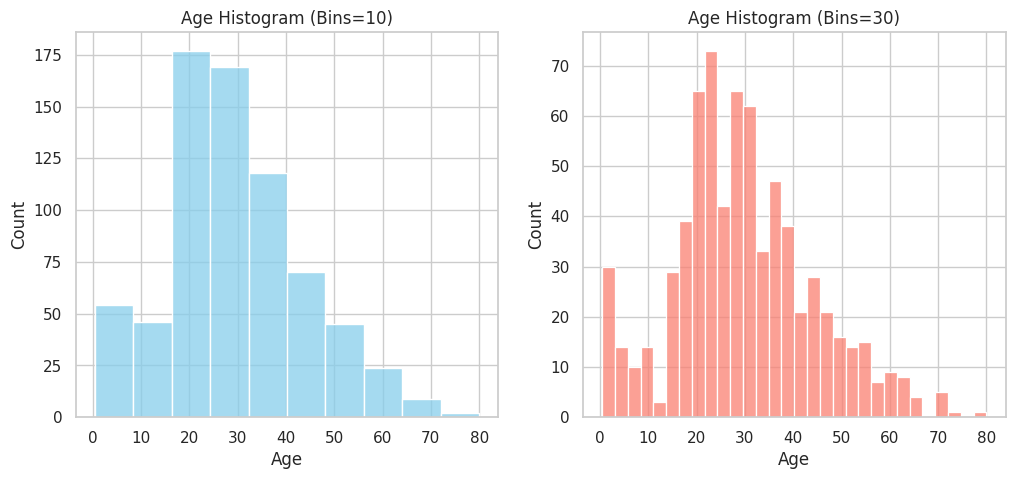

In [16]:
# 1) Histogram (Age)
# Create a histogram of Age (e.g., using sns.histplot).
# Try at least two di!erent bin sizes (e.g., 10 and 30).

# write your code
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=df, x='Age', bins=10, kde=False, color='skyblue')
plt.title('Age Histogram (Bins=10)')

plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Age', bins=30, kde=False, color='salmon')
plt.title('Age Histogram (Bins=30)')

plt.show()

Q. Compare how the shape changes and which bin size you prefer and why.  
A. bin size가 10인 경우 자세한 분포가 아닌 대략적인 분포만 보이지만, bin size를 30으로 늘려 분포를 그려보면 보다 자세한 분포를 얻을 수 있다. 특히 0-10세 사이의 분포에서 그 특징이 두드러지게 나타난다.
선호하는 bin size는 30이다. 구간이 더 세세하게 나뉘어 있어 나이에 따른 생존여부를 더욱 정확히 파악할 수 있기 때문이다.

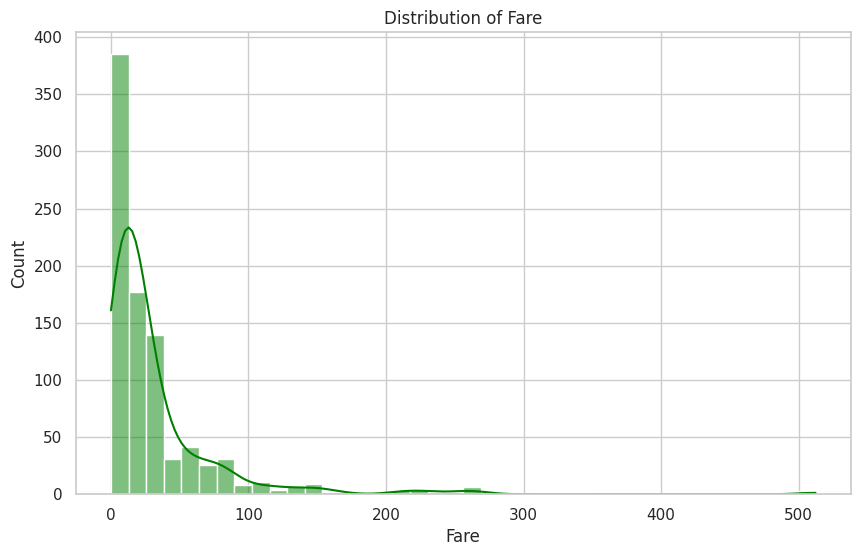

In [8]:
# 2) Histogram or KDE (Fare)
# Plot the distribution of Fare with a histogram, optionally with KDE.

# write your code
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Fare', kde=True, bins=40, color='green')
plt.title('Distribution of Fare')
plt.show()

Skewness: 4.787316519674893


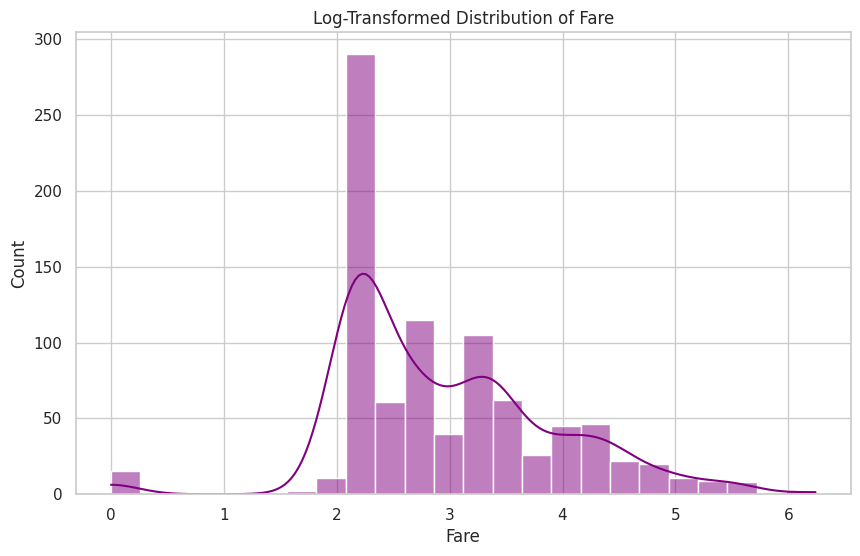

In [9]:
# Comment on skewness and outliers; suggest a possible transformation (e.g., log).

# write your code
print(f"Skewness: {df['Fare'].skew()}")

# log trans
plt.figure(figsize=(10, 6))
sns.histplot(x=np.log1p(df['Fare']), kde=True, color='purple')
plt.title('Log-Transformed Distribution of Fare')
plt.show()

**comment**: skewness의 값이 양수값이 나온것으로 보아 KDE로 분석한 fare의 분포가 right-skewed의 형태를 띄고 있다. 이는 대부분의 승객들은 저렴한 요금을 지불했지만, 극소수의 승객을이 고액을 지불한 것으로 유추할 수 있다. 이러한 outlier들을 학습데이터에 포함하게 된다면 모델의 성능에 영향을 줄 수 있으므로 그 영향을 줄이기 위해 log변환을 이용하여 normal distribution에 가깝게 조정하는 것이 좋을 것 같다.

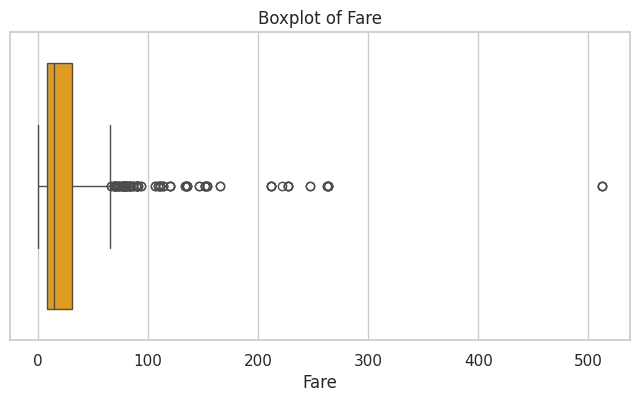

In [10]:
# 3) Boxplot (Fare)
# Produce a boxplot of Fare.

# write your code
plt.figure(figsize=(8, 4))
sns.boxplot(x='Fare', data=df, color='orange')
plt.title('Boxplot of Fare')
plt.show()

In [11]:
# Identify approximate median and presence of extreme outliers.

# write your code
median_fare = df['Fare'].median()
print(f"Median Fare: {median_fare}")

Median Fare: 14.4542


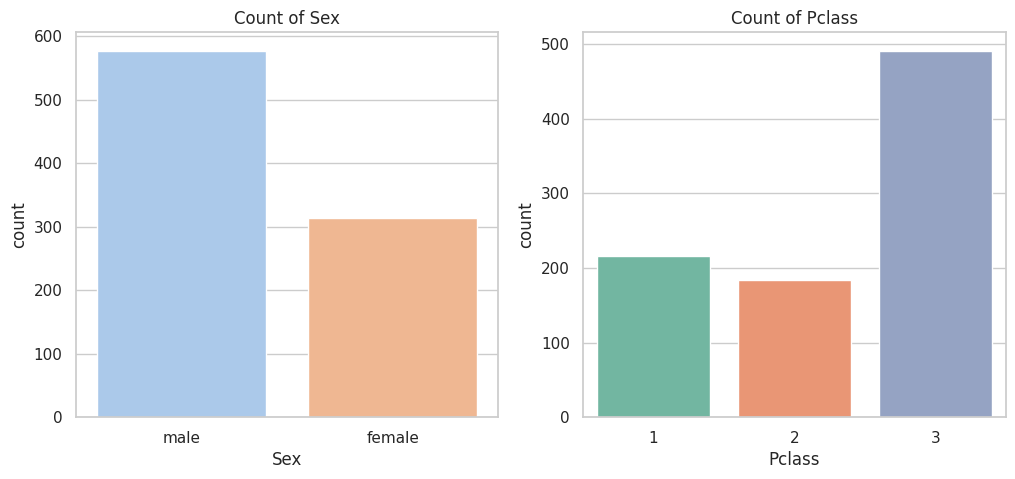

In [13]:
# 4) Countplot (Sex, Pclass)
# Create countplots for Sex and Pclass.

# write your code
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Sex', data=df, ax=ax[0], palette='pastel', hue='Sex', legend=False)
ax[0].set_title('Count of Sex')

sns.countplot(x='Pclass', data=df, ax=ax[1], palette='Set2', hue='Pclass', legend=False)
ax[1].set_title('Count of Pclass')

plt.show()

Q. Discuss class imbalance and how it might affect survival analysis.  
A. sex분포를 보면 남성이 여성보다 거의 2배 많은 것, Pclass 분포를 보면 3등석 승객이 1, 2등석 승객보다 2배 이상 많은 것을 확인할 수 있다. 따라서, 분석 후 단순히 생존자의 "수"만 비교하였을 때는 남성과 3등석 승객이 많아보일 수 있겠지만, 탑승한 모든 승객수 자체에 편차가 있으므로 생존한 "비율"로 판단해야 할 것이다.

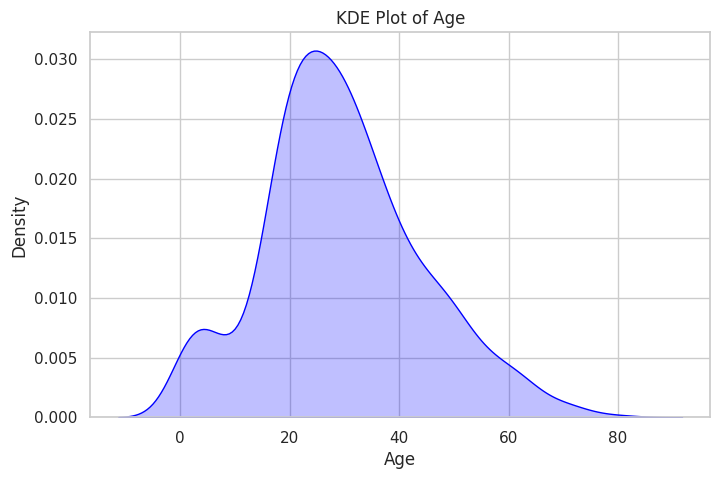

In [14]:
# 5) KDE Plot (Age)
# Plot a KDE of Age.

# write your code
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age', fill=True, color='blue')
plt.title('KDE Plot of Age')
plt.show()

Q. Compare it to the histogram from 1): what does KDE reveal that
the histogram does not?  
A. KDE는 히스토그램과 달리 끊김없이 continuous한 형태로 나타난다. 이를 통해 0세에서 약 25세까지 서서히 증가하다 정점을 찍고 이후로 80세까지 감소하는 분포를 확인할 수 있다.

Q. Summary Paragraph. Write a short paragraph (5–7 sentences) summarizing what you learned about the marginal distributions of Age, Fare, Sex, and Pclass. Explicitly state which variable(s) you expect to be most predictive of survival and why.  
A. univariate visualization을 통해 각 요소가 결과에 미친 영향을 확인할 수 있었다. 첫번째로 age의 경우, normal distribution과 거의 유사한 형태를 띄고 있다. 두번째로, fare의 경우, right-skewed이므로 로그변환이 필요하다. 마지막으로, sex와 Pclass의 경우 남성과 3등급의 수가 압도적으로 많으므로 이를 고려해야 할 것이다. 예상컨데, 재난 상황에서 아이와 여성을 먼저 구조하는 경향이 있고, 등급별 좌석 위치가 다를 것이기에 age, sex와 Pclass가 생존율에 큰 영향을 미쳤을 것으로 예상된다.

# 2. Bivariate Visualizations

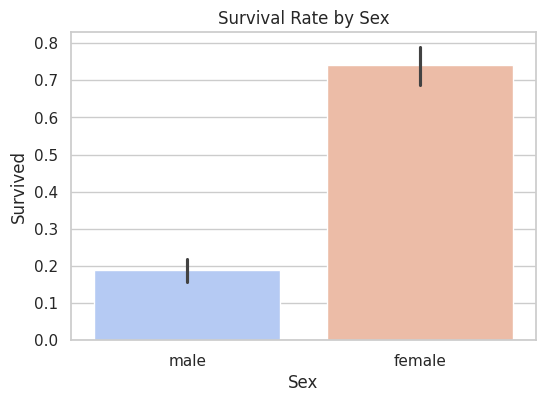

In [18]:
# 1) Barplot: Survival Rate by Sex
# Plot survival rate by Sex using a barplot (sns.barplot).

# write your code
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df, palette='coolwarm', hue = 'Sex', legend=False)
plt.title('Survival Rate by Sex')
plt.show()

Q. Quantify the difference in survival rate between males and females
(approximate percentages).  
A. 남성의 생존률은 20%가 채 안되지만, 여성의 생존률은 70%이상이다. 이 둘의 차이는 극명하게 나타난다.

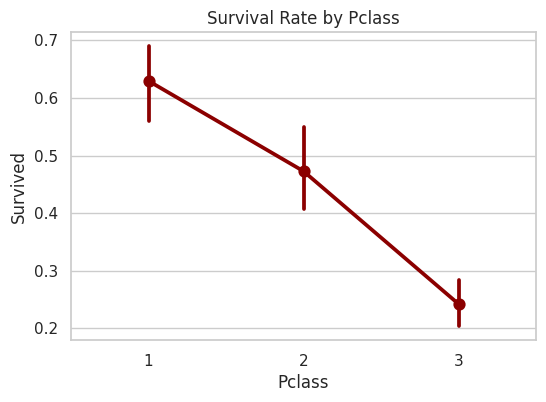

In [19]:
# 2) Barplot or Pointplot: Survival Rate by Pclass
# Plot survival rate vs. Pclass (sns.pointplot or sns.barplot).

# write your code
plt.figure(figsize=(6, 4))
sns.pointplot(x='Pclass', y='Survived', data=df, color='darkred')
plt.title('Survival Rate by Pclass')
plt.show()

Q. Comment on how survival probability changes with passenger class.  
A. 등급이 3등석으로 갈수록(낮아질수록) 생존률이 감소하는 것으로 보인다. 거의 선형적인 비율이 나타나는것을 확인할 수 있다.

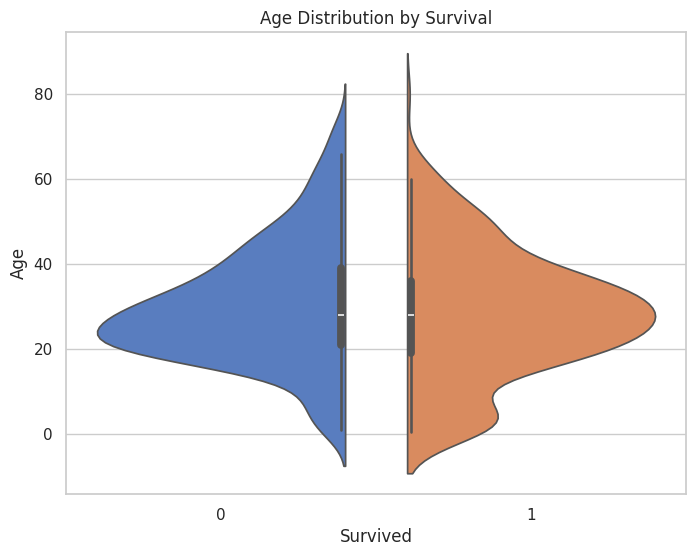

In [24]:
# 3) Violinplot or Boxplot: Age by Survival
# Plot Age (y-axis) versus Survived (x-axis) using a violinplot or boxplot.

# write your code
plt.figure(figsize=(8, 6))
sns.violinplot(x='Survived', y='Age', data=df, palette='muted', split=True, hue='Survived', legend=False)
plt.title('Age Distribution by Survival')
plt.show()

Q. Discuss differences in the distributions of age for survivors vs. non-survivors (e.g., medians, spread, presence of children).  
A. 영유아에 해당하는 0세-10세 사이의 분포가 생존에서 볼록하게 튀어나온것으로 보아 영유아의 생존률이 높은것을 확인할 수 있다. 이외에 중간값과 분포값은 생존과 사망에서 큰 차이를 보이지 않는다.

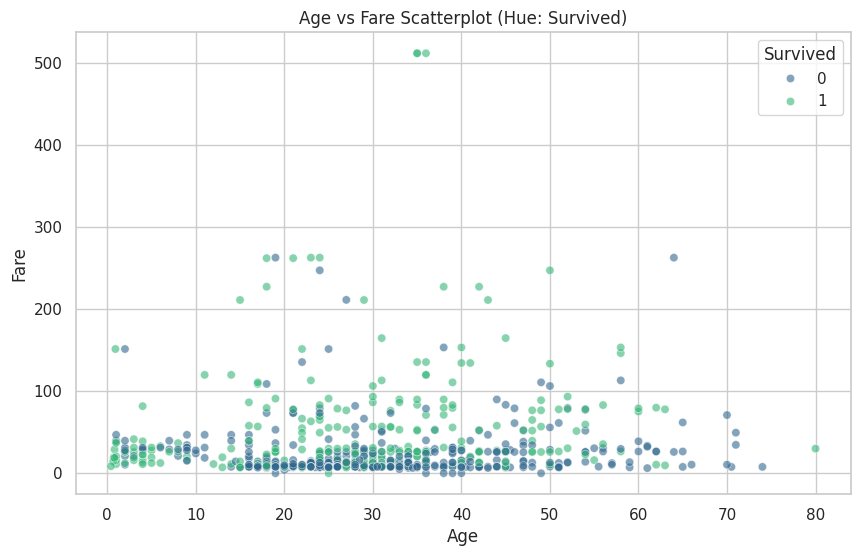

In [25]:
# 4) Scatterplot: Age vs. Fare (colored by Survived)
# Create a scatterplot of Age vs. Fare, with color (hue) indicating Survived.
# Optionally, adjust point transparency (alpha) for dense regions.
# Identify any visible cluster(s) associated with higher survival rates.

# write your code
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df, alpha=0.6, palette='viridis')
plt.title('Age vs Fare Scatterplot (Hue: Survived)')
plt.show()

**cluster identification:** 분포의 상단부분 즉, 요금을 많이 낸 승객들에 생존자들이 많이 모여있는 것을 확인할 수 있다.

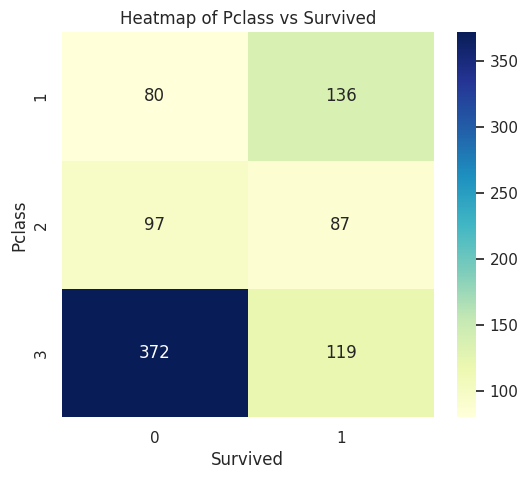

In [26]:
# 5) Crosstab and Heatmap: Pclass vs. Survived
# Create a crosstab of Pclass and Survived.
# Visualize it with a heatmap.

# write your code
ct = pd.crosstab(df['Pclass'], df['Survived'])
plt.figure(figsize=(6, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Pclass vs Survived')
plt.show()

Q. Interpret which combinations of class and survival are most/least frequent.  
A. most frequent인 combinations은 3등석의 사망자이고, least frequent는 1등석의 사망자이다. 특이한 점은, 1등석의 경우 사망자보다 생존자가 더 많다는 것이다.

Q. Short Reflection. Write 3–5 bullet points summarizing the strongest bivariate relationships with survival (e.g., Sex, Pclass, Fare, Age).  
A. sex의 경우 여성이 남성에 비해 월등히 생존율이 높다. Pclass의 경우 가장 높은 등급인 1등석이 가장 생존율이 높았고, 낮은 등급으로 갈수록 생존률이 선형으로 감소함을 확인할 수 있다. 다음으로 Fare의 경우 요금을 많이 지불할 수록 생존율이 증가하였다. 이는 Pclass와의 연관성으로도 생각해볼 수 있을 것 같다. 마지막으로 age의 경우 영유아의 생존율이 가장 높음을 확인할 수 있었다.

# 3. Multivariate Visualizations

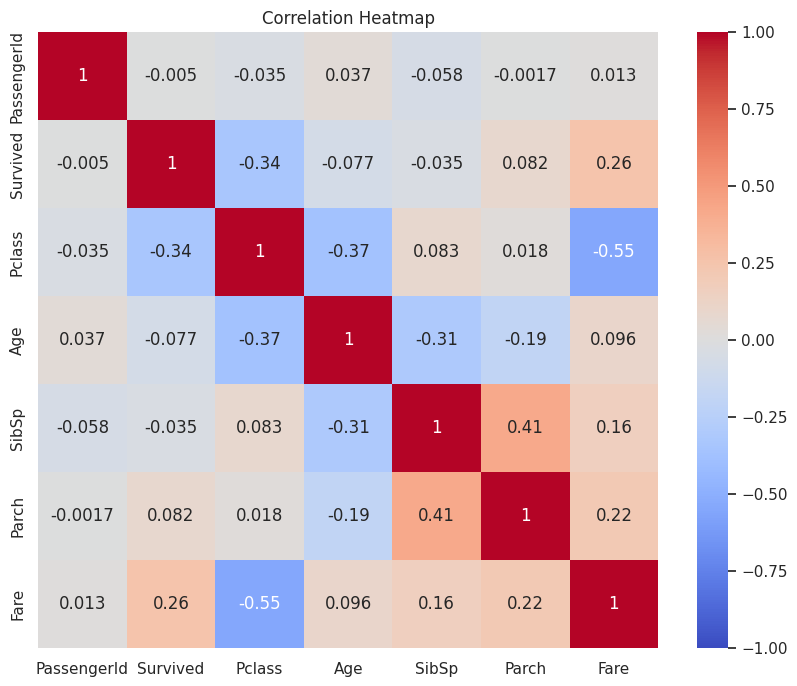

In [28]:
# 1) Correlation Heatmap
# Compute a correlation matrix for numeric features (e.g., Survived, Pclass, Age, SibSp, Parch, Fare).
# Plot it using a heatmap with annotations.

# write your code
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

Q. Identify the top two positive and top two negative correlations involving Survived.  
A. survived와 관련된 positive correlation은 순서대로 fare, parch이고, negative correlation은 순서대로 Pclass와 Age이다.

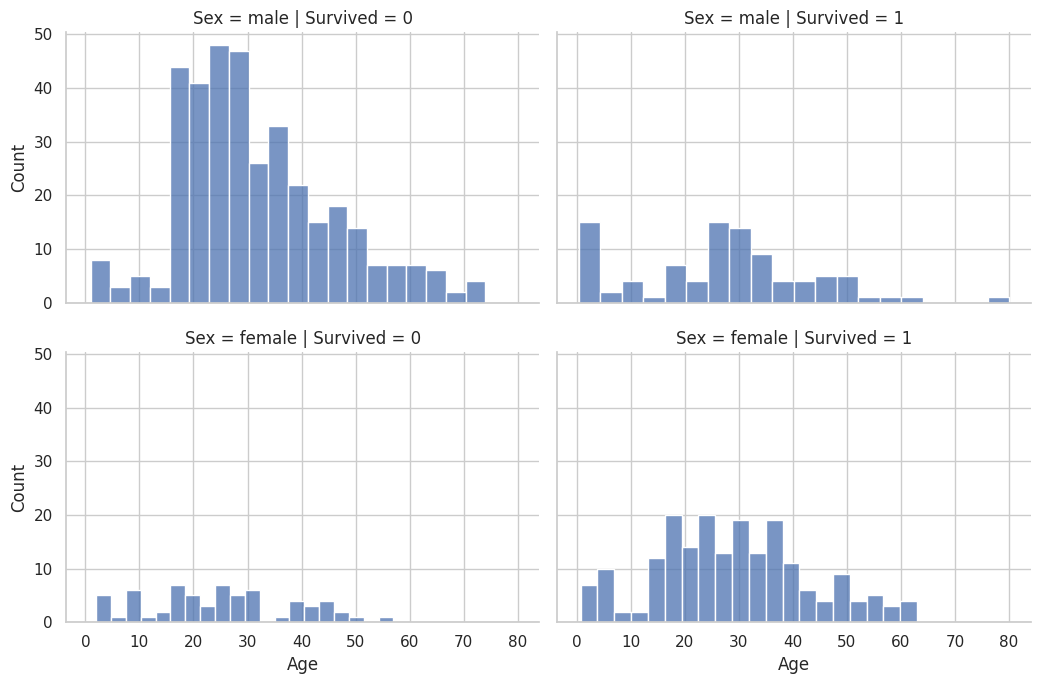

In [29]:
# 2) FacetGrid: Age by Sex and Survival
# Use a facet grid (e.g., sns.FacetGrid) to plot Age histograms conditioned on Sex (rows) and Survived (columns).

# write your code
g = sns.FacetGrid(df, row='Sex', col='Survived', height=3.5, aspect=1.5)
g.map(sns.histplot, 'Age', bins=20)
g.add_legend()
plt.show()

Q. Describe how the Age distribution di!ers across the four panels (male/female vs. survived/died).  
A. 여성의 경우 survive와 died모두 고르게 분포함을 확인할 수 있다. 반면, 남성의 경우, 20-30대 사망자가 압도적으로 많고, 영유아에서 눈에 띄게 생존자가 많이 존재함을 확인할 수 있다.

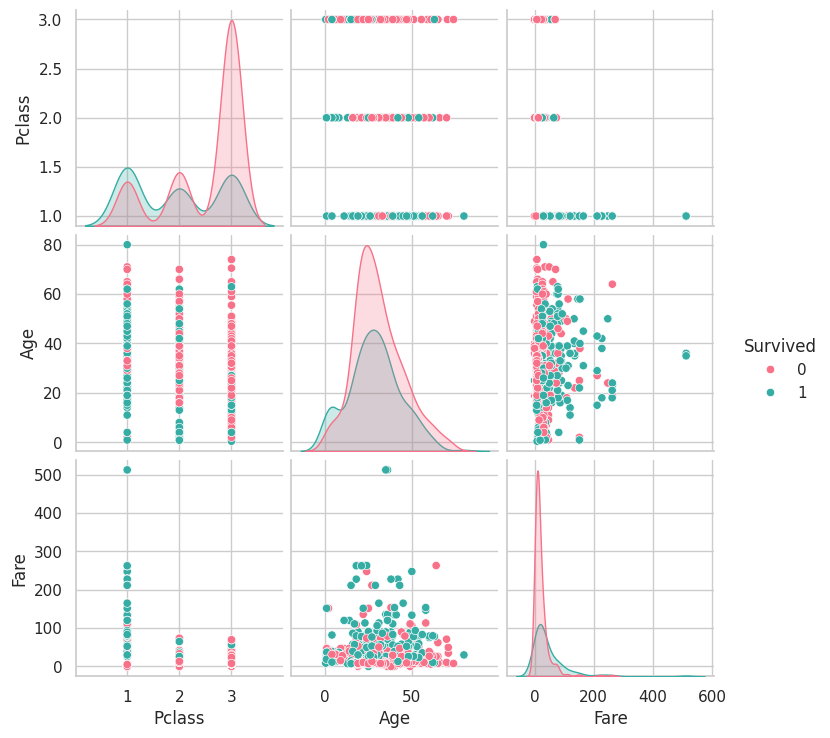

In [30]:
# 3) Pairplot
# Create a pairplot for a subset of variables (e.g., Survived, Pclass, Age, Fare).
# Use hue=’Survived’ to color points.

# write your code
subset_vars = ['Survived', 'Pclass', 'Age', 'Fare']
sns.pairplot(df[subset_vars], hue='Survived', palette='husl', diag_kind='kde')
plt.show()

Q. Identify any pair of variables where survivors and non-survivors appear well separated.  
A. Pclass와 fare의 관계에서 두드러지게 나타난다. 특히 Pclass가 낮고(1등석) fare가 높은 영역에서 생존자가 몰려있는 것이 잘 구분되어 있다.

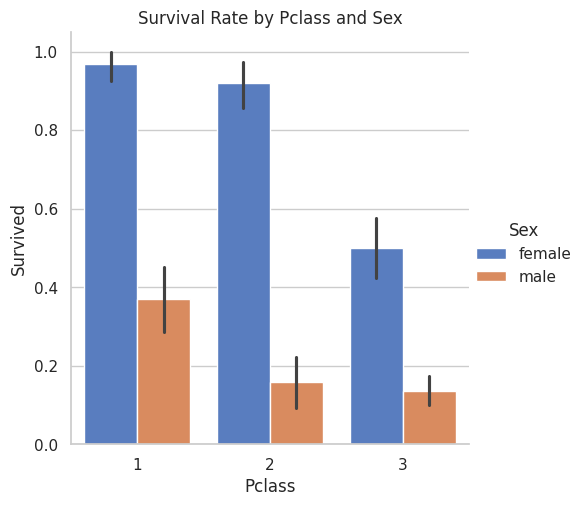

In [31]:
# 4) Catplot: Survival by Pclass and Sex
# Create a categorical plot (e.g., sns.catplot with kind=’bar’) showing survival rate by Pclass and Sex (as hue).

# write your code
sns.catplot(x='Pclass', y='Survived', hue='Sex', kind='bar', data=df, palette='muted')
plt.title('Survival Rate by Pclass and Sex')
plt.show()

Q. Discuss which subgroup (e.g., 1st class females) has the highest
survival rate and which has the lowest.  
A. 1등석 여성이 가장 높은 생존율을 가지고 있고, 3등석 남성이 가장 낮은 생존율을 갖고 있다.

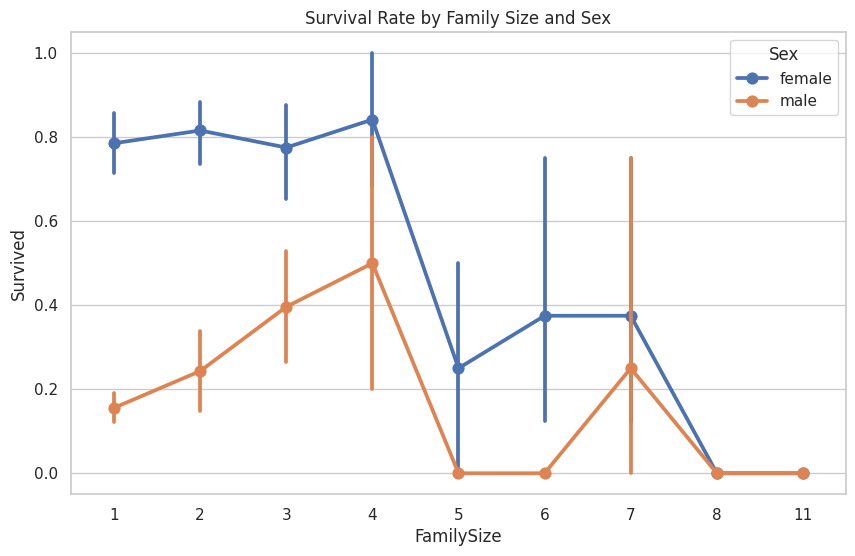

In [32]:
# 5) Design Your Own Multivariate Plot
# Propose and implement one additional multivariate visualization not directly shown in the slides (e.g., a facet scatterplot, stacked bar chart, or jointplot).

# write your code
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(10, 6))
sns.pointplot(x='FamilySize', y='Survived', hue='Sex', data=df, palette='deep')
plt.title('Survival Rate by Family Size and Sex')
plt.show()

Q. Explain the design choices (axes, hues, facets) and what new insight it provides beyond previous plots.  
A. FamilySize라는 새로운 변수를 도입하였다. x축에 family size를, y축에 survived를 설정하였고, sex를 hue로 사용하여 가족 규모가 성별에 미치는 영향을 알아보았다. 가족 구성원이 4명 이하인 경우, 생존율이 가장 높았고, 5명 이상이 되면 급격히 떨어짐을 확인할 수 있다.

# 4. Evaluation Visualizations

Assume you have trained at least two models (e.g., Logistic Regression
and Random Forest).

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

data = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']].copy()
data['Age'] = data['Age'].fillna(data['Age'].median())
data['Sex'] = LabelEncoder().fit_transform(data['Sex'])

X = data.drop('Survived', axis=1)
y = data['Survived']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Model A: Logistic Regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_score = logreg.score(X_val, y_val)

# Model B: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_score = rf.score(X_val, y_val)

print(f"Logistic Regression Score: {logreg_score:.4f}")
print(f"Random Forest Score: {rf_score:.4f}")

Logistic Regression Score: 0.8045
Random Forest Score: 0.8045


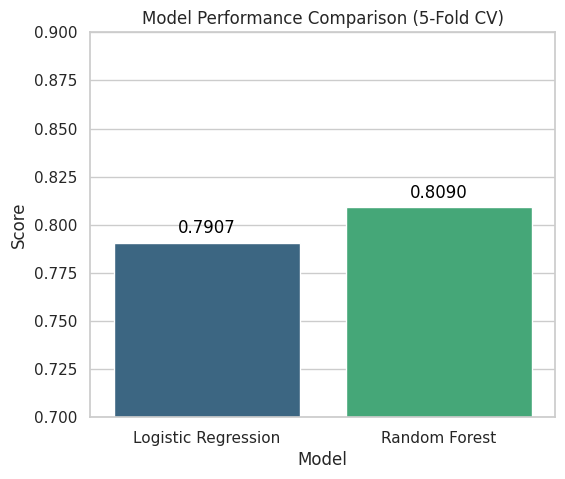

In [54]:
# 1) Model Score Barplot
# Create a small DataFrame with model names and their cross-validation scores.
# Plot a barplot comparing model scores.

# write your code
from sklearn.model_selection import cross_val_score

logreg_cv = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
rf_cv = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')

scores_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Score': [logreg_cv.mean(), rf_cv.mean()]
})

plt.figure(figsize=(6, 5))
sns.barplot(x='Model', y='Score', data=scores_df, palette='viridis', hue='Model', legend=False)
plt.ylim(0.7, 0.9)
plt.title('Model Performance Comparison (5-Fold CV)')

for index, row in scores_df.iterrows():
    plt.text(index, row.Score + 0.005, f"{row.Score:.4f}", color='black', ha="center")

plt.show()

Q. Comment on which model you would choose and why.  
A. random forest의 score가 더 높으니 random forest model을 선택할 것이다.

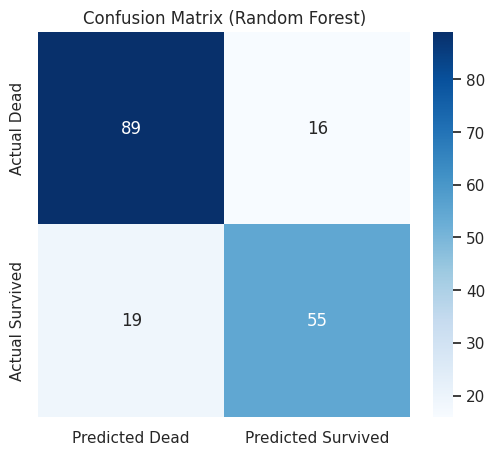

In [55]:
# 2) Confusion Matrix
# For one chosen model, compute and plot a confusion matrix on the training or validation set.

# write your code
y_pred = rf.predict(X_val)
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Dead', 'Predicted Survived'],
            yticklabels=['Actual Dead', 'Actual Survived'])
plt.title('Confusion Matrix (Random Forest)')
plt.show()

Q. Interpret each cell (TP, TN, FP, FN) in the context of Titanic survival.  
A. TP는 실제 생존자를 생존자로 올바르게 예측한 것으로 55건, TN은 실제 사망자를 사망자로 올바르게 에측한 것으로 89건, FP는 실제 사망자를 생존자로 잘못 예측한 것으로 16건, FN은 실제 생존자를 사망자로 잘못 예측한 것으로 19건이다.

Q. Discuss the trade-off between correctly predicting survivors vs.
non-survivors.  
A. 더많은 생존자를 찾으려하면, 사망자를 생존자로 잘못예측하는 FP오류가 증가할 수 있다.

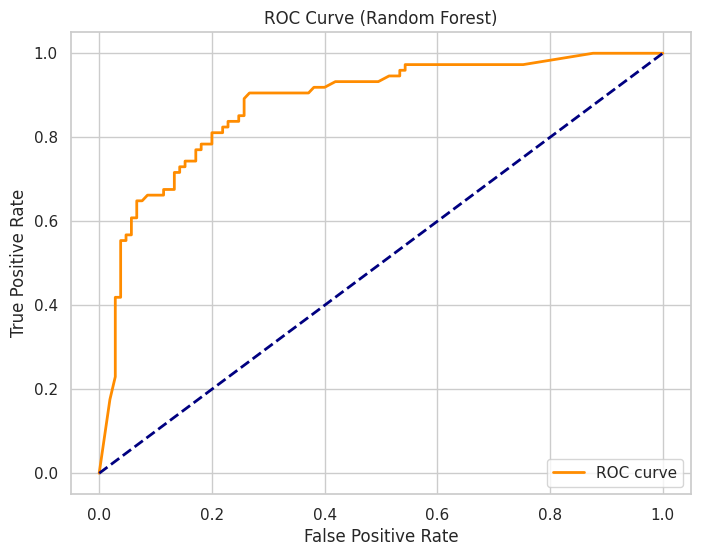

In [56]:
# 3) ROC Curve (Bonus)
# Plot the ROC curve for one model using predicted probabilities.

# write your code
y_prob = rf.predict_proba(X_val)[:, 1]

fpr, tpr, thresholds = roc_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')
plt.legend(loc="lower right")
plt.show()

In [57]:
# Compute and report the AUC.

# write your code
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f}")

AUC Score: 0.8790


Q. Briefly discuss how the ROC curve complements accuracy and
confusion matrix.  
A. 위 모델에서 AUC 값이 0.8790이 나왔다. AUC score이 1에 가까울 수록 좋은 모델이다. ROC curve는 분포가 불균형할 때 accuracy보다 model의 변별력에 대해 더욱 신뢰할 수 있는 지표이다.

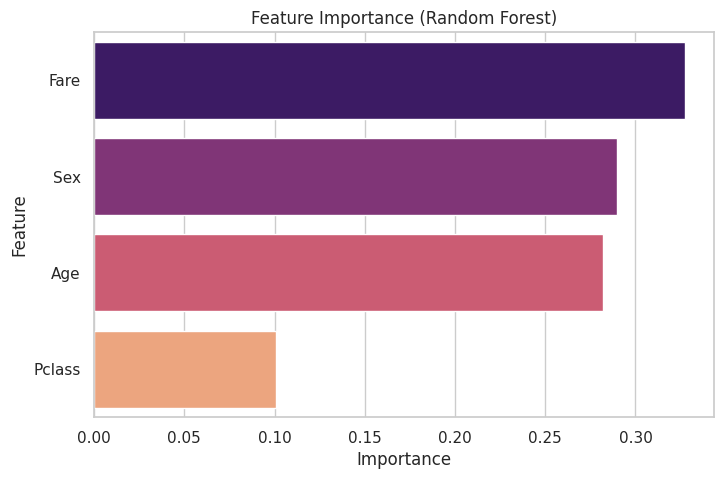

In [58]:
# 4) Feature Importance Plot (Bonus)
# For a tree-based model (e.g., Random Forest), plot feature importances as a horizontal bar chart.

# write your code
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importances, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance (Random Forest)')
plt.show()

Q. Compare the visual importance ranking with the relationships you
observed in your earlier visualizations.  
A. fare, sex, age, Pclass 순으로 중요도가 나타났다. 위에서 예측하였을 때는 Pclass가 영향을 많이 미칠 것으로 생각하였는데, 좋은 좌석일 수록 요금도 비싸지기에 위에서 진행한 예측은 fare에 대한 예측으로도 생각할 수 있을 것 같다. age와 sex는 여전히 결정적인 변수로 작용하고 있음을 확인할 수 있다.